# Server Evaluation

This File reads all csv files of the ./server folder and concatenates them to a single dataframe, then used for further evaluation.

In [12]:
import pandas as pd
import glob
import os
import seaborn as sns
import matplotlib.pyplot as plt

In [13]:
folder_path = './server'  

csv_files = glob.glob(os.path.join(folder_path, '*.csv'))

df = pd.concat((pd.read_csv(file, delimiter=", ", engine="python") for file in csv_files), ignore_index=True)

In [14]:
df

,Transport Protocol,Scenario,Distance (m),Transfer Speed (Mbps),Package Loss (%),Package Size (Bytes),Number of Packages
0,QUIC,Inner City,10,8.755858,0.000000,128,100
1,QUIC,Inner City,30,250.596146,0.000000,4096,10000
2,QUIC,Inner City,30,111.145760,0.000000,4096,100
3,TCP,Inner City,30,70.239204,0.000000,4096,1000
4,TCP,Inner City,30,252.828583,0.000000,9216,10000
...,...,...,...,...,...,...,...
241,UDP,Inner City,10,74.781906,92.150002,9216,10000
242,UDP,Inner City,1,203.073242,0.000000,4096,100
243,QUIC,Inner City,30,254.077469,0.000000,9216,10000
244,QUIC,Inner City,10,38.211098,0.000000,128,10000


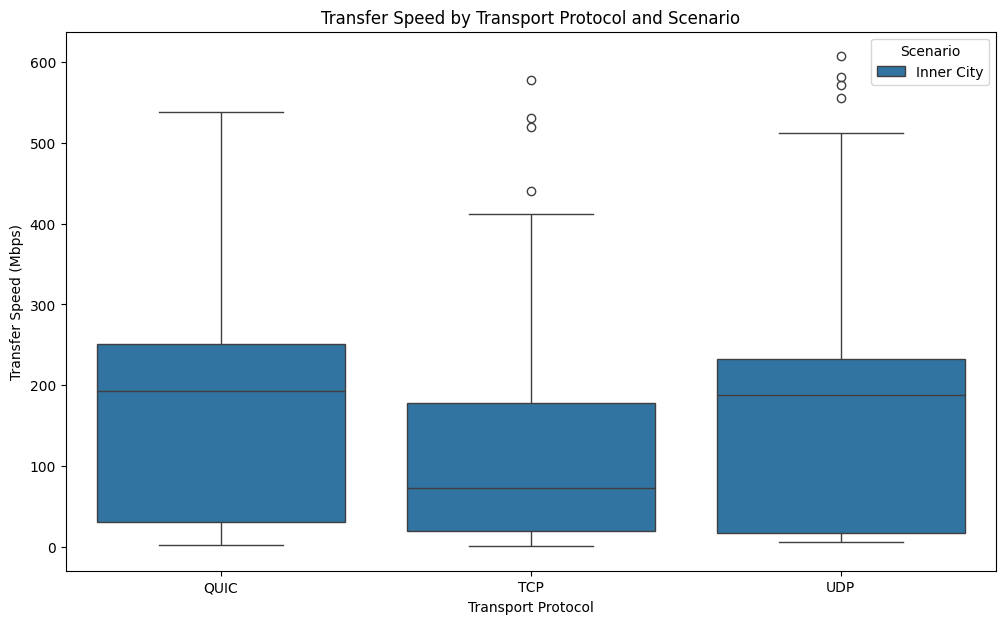

In [15]:
plt.figure(figsize=(12, 7))
sns.boxplot(x='Transport Protocol', y='Transfer Speed (Mbps)', hue='Scenario', data=df)
plt.title('Transfer Speed by Transport Protocol and Scenario')
plt.ylabel('Transfer Speed (Mbps)')
plt.xlabel('Transport Protocol')
plt.legend(title='Scenario')
plt.show()

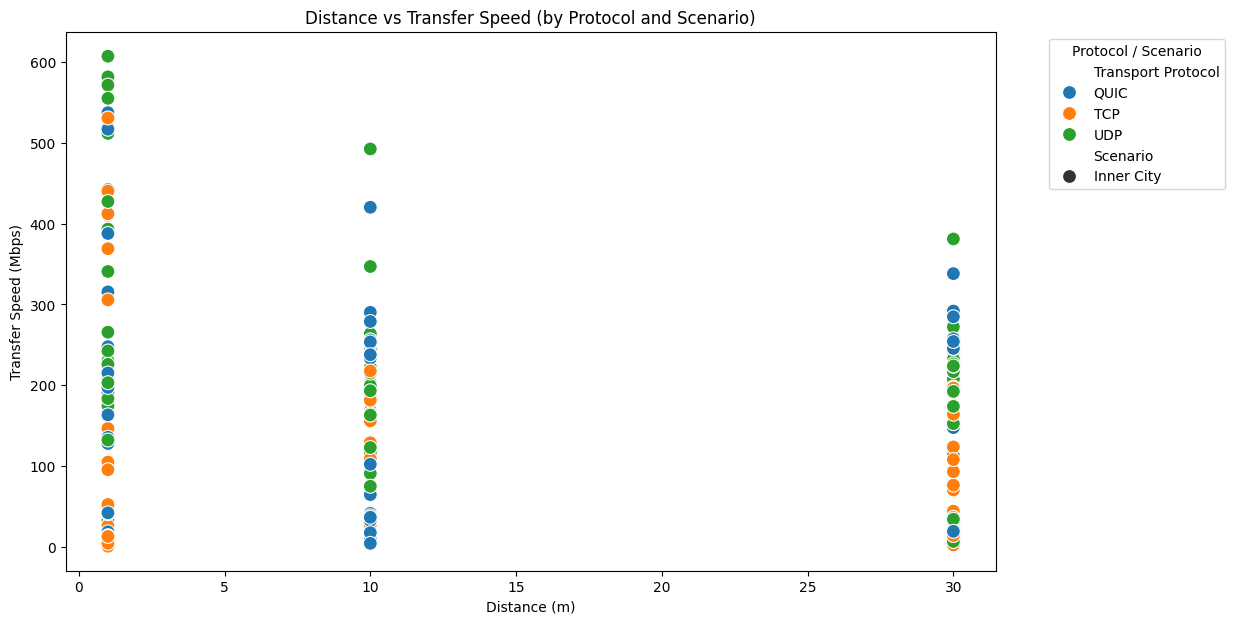

In [16]:
plt.figure(figsize=(12, 7))
sns.scatterplot(x='Distance (m)', y='Transfer Speed (Mbps)', hue='Transport Protocol', style='Scenario', data=df, s=100)
plt.title('Distance vs Transfer Speed (by Protocol and Scenario)')
plt.xlabel('Distance (m)')
plt.ylabel('Transfer Speed (Mbps)')
plt.legend(title='Protocol / Scenario', bbox_to_anchor=(1.05, 1), loc=2)
plt.show()

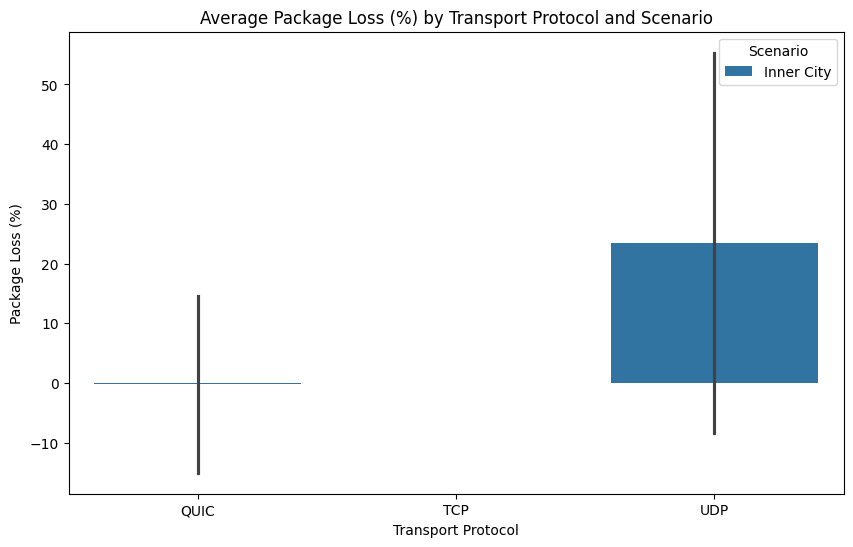

In [17]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Transport Protocol', y='Package Loss (%)', hue='Scenario', data=df, estimator='mean', errorbar='sd')
plt.title('Average Package Loss (%) by Transport Protocol and Scenario')
plt.ylabel('Package Loss (%)')
plt.xlabel('Transport Protocol')
plt.legend(title='Scenario')
plt.show()

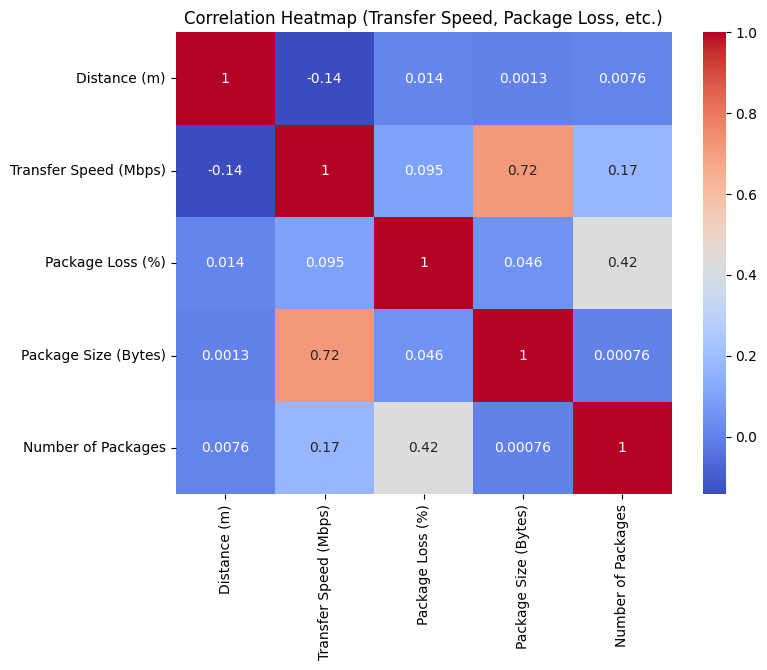

In [18]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap (Transfer Speed, Package Loss, etc.)')
plt.show()